In [1]:
import sys
sys.path.append("../drivers/")
from tn2211_drivers import *
import pyvisa
import matplotlib.pyplot as plt

Loading BokehJS ...

In [2]:
import time

In [3]:
rm = pyvisa.ResourceManager()

In [4]:
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR')

In [5]:
scope = Scope("SDS")

Connecting to scope at resource: USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR
Setting memory depth to 10k points


In [6]:
scope.write("ACQ:MDEP 1M")

In [7]:
scope.get_trace("F1", 1e6)

Retreiving 1000000 points
points 1000000.0
len(recv_byte) 2097152


error: unpack requires a buffer of 2000000 bytes

In [5]:
gen = Geneartor("SDG")

Connecting to scope at resource: USB0::0xF4EC::0x1103::SDG1XDDQ802940::INSTR


In [6]:
scope.get_trace(1)

Retreiving 10000 points


(array([0.0025    , 0.0025    , 0.0025    , ..., 0.00251999, 0.00252   ,
        0.00252   ], shape=(10000,)),
 array([-0.025     , -0.03125   , -0.03125   , ...,  1.88541667,
         1.8875    ,  1.88125   ], shape=(10000,)))

In [8]:
scope.get_trace(1,npoints="all")

Retreiving 2500000 points


(array([0.0025    , 0.0025    , 0.0025    , ..., 0.00749999, 0.0075    ,
        0.0075    ], shape=(2500000,)),
 array([-0.025     , -0.02291667, -0.025     , ..., -0.025     ,
        -0.01875   , -0.01875   ], shape=(2500000,)))

In [2]:
!rm *.dat
!rm ../lab\ session\ notebooks/*.dat
!rm ../lab\ session\ notebooks/*.png

zsh:1: no matches found: *.dat


In [5]:
gen.set_frequency(1,1e3)

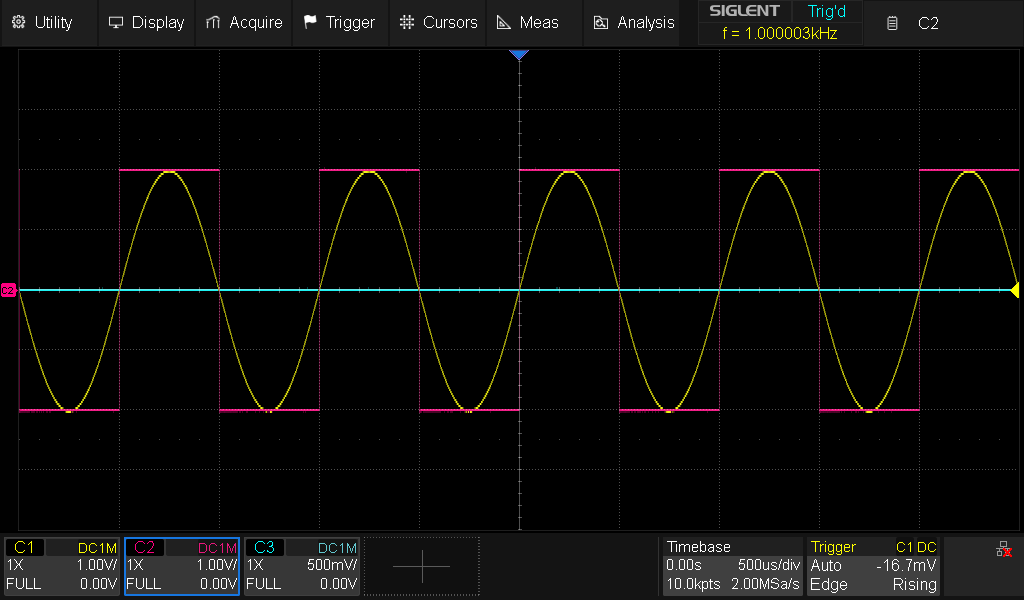

In [6]:
scope.get_screenshot()

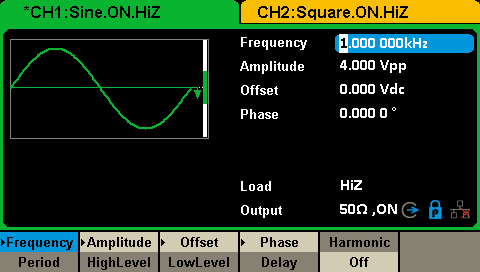

In [7]:
gen.get_screenshot()

In [8]:
gen.set_frequency(1,1e6)

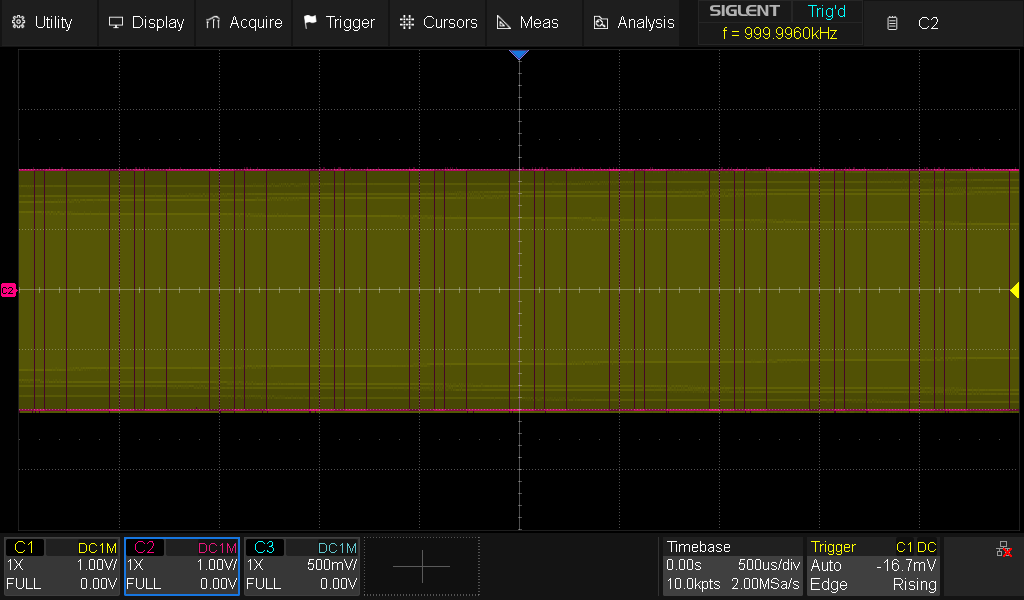

In [9]:
scope.get_screenshot()

In [10]:
help(scope.get_trace)

Help on method get_trace in module tn2211_drivers:

get_trace(channel_number, npoints=10000, save_file=True) method of tn2211_drivers.Scope instance



In [5]:
t,v = scope.get_trace(1)

Total trace points: 10000
Retreiving 10000 points


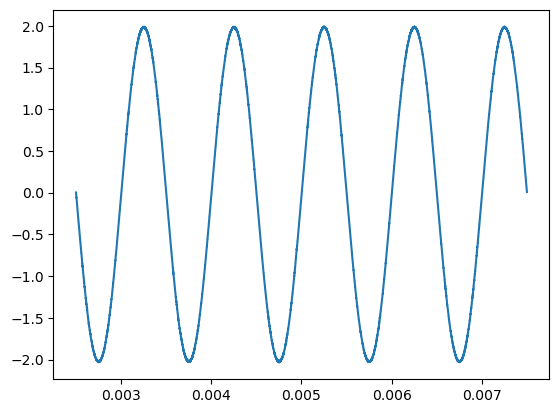

In [6]:
plt.plot(t,v)

In [7]:
bokeh_plot(t,v)

In [9]:
!rm *.dat *.png